In [ ]:
%tensorflow_version 1.x

TensorFlow 1.x selected.


In [ ]:
pip install keras_layer_normalization

  Created wheel for keras-layer-normalization: filename=keras_layer_normalization-0.14.0-cp36-none-any.whl size=5268 sha256=243cb91bc557b9b4bef40958e311d6d1291301e28873c756789cdfd0c760b34a
  Stored in directory: /root/.cache/pip/wheels/54/80/22/a638a7d406fd155e507aa33d703e3fa2612b9eb7bb4f4fe667
Successfully built keras-layer-normalization


In [ ]:
import os
import random
import scipy.io
import keras
import tensorflow as tf
from google.colab.patches import cv2_imshow
import numpy as np
from glob import glob
from google.colab import drive
import matplotlib.pyplot as plt

from keras.layers import Conv2DTranspose, ConvLSTM2D, BatchNormalization, TimeDistributed, Conv2D, Flatten, Dense, MaxPooling2D
from keras.models import Sequential, load_model
from keras_layer_normalization import LayerNormalization

drive.mount('/content/gdrive',force_remount=True)   

Using TensorFlow backend.


Mounted at /content/gdrive


In [ ]:
FUSION2020_FOLDER_PATH = "/content/gdrive/My Drive/FUSION2020"
#FUSION2020_FOLDER_PATH = "/content/gdrive/My Drive/escritorio/Doctorado/2019-2020/Congresos/FUSION2020"
NUMBER_OF_EXAMPLES_FOR_EACH_CLASS = 60
NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION = 5
NUMBER_OF_SAMPLES_TO_IGNORE = 0
EXPERIMENTS = 20

In [ ]:

def get_training_and_validation_example_list(path, number_of_examples):
  training_matrix_paths = []
  for i in range(1, number_of_examples+1):
    training_matrix_paths = training_matrix_paths + glob(os.path.join(path, "*_{}.mat".format(i)))
  return training_matrix_paths

def get_ignore_example_lists(path, number_of_examples_to_ignore, number_of_examples_to_use_for_validation):
  ignore_example_list = []
  for i in range(number_of_examples_to_use_for_validation+1, number_of_examples_to_use_for_validation + number_of_examples_to_ignore+1):
    ignore_example_list = ignore_example_list + glob(os.path.join(path, "*_{}.mat".format(i)))
  return ignore_example_list

def get_all_matrix_paths(path):
  number_of_matrix_paths = len(glob(os.path.join(path, "*.mat")))
  all_matrix_paths = []
  for i in range(1, number_of_matrix_paths+1):
    all_matrix_paths = all_matrix_paths + glob(os.path.join(path, "*_{}.mat".format(i)))
  return all_matrix_paths

def change_matrix_index(matrix):
  new_matrix = np.zeros([21,50,28])
  for i in range(matrix.shape[2]):
    new_matrix[i,:,:] = matrix[:,:,i]
  return new_matrix

def read_all_matrix_from_object_folder_obtaining_training_and_evaluation(path, number_of_training_examples, number_of_examples_to_ignore):
  all_matrix_paths = get_all_matrix_paths(path)
  training_matrix_paths = get_training_and_validation_example_list(path,number_of_training_examples)
  ignore_example_list = get_ignore_example_lists(path, number_of_examples_to_ignore, number_of_training_examples)
  print(training_matrix_paths)
  training_object_data = None
  evaluation_object_data = None
  training_matrix_index = 0
  evaluation_matrix_index = 0

  for matrix_path in all_matrix_paths:
    if not matrix_path in ignore_example_list:
      matrix = scipy.io.loadmat(matrix_path)
      matrix = change_matrix_index(matrix["frames2"])
      print("Matrix {} shape".format(matrix_path))
      print(matrix.shape)
      if matrix_path in training_matrix_paths:
        if training_object_data is None:
          training_object_data = -1 * np.ones((len(training_matrix_paths), matrix.shape[0], matrix.shape[1], matrix.shape[2]))
        training_object_data[training_matrix_index] = matrix
        training_matrix_index += 1   

      else:
        if evaluation_object_data is None:
          evaluation_object_data = -1 * np.ones((NUMBER_OF_EXAMPLES_FOR_EACH_CLASS-len(training_matrix_paths) - number_of_examples_to_ignore, matrix.shape[0], matrix.shape[1], matrix.shape[2]))
        evaluation_object_data[evaluation_matrix_index] = matrix
        evaluation_matrix_index += 1

  print(training_object_data.shape)
  print(evaluation_object_data.shape)
  return training_object_data, evaluation_object_data

def read_training_and_evaluation_objects_data(path,number_of_training_examples, number_of_examples_to_ignore):
  nom_labels = ["ball_l_", "basket_ball_", "coke_bottle_", "energy_drink_can_", "gears_box_", "grey_mouse_", "mixed_nut_", "mixed_washer_", "mouse_", "nestea_bottle_",
                "nut_m6_", "nut_m8_", "nut_m10_", "rivets_box_", "roll_wheel_", "rubber_pipe_", "soda_can_", "sponge_rough_", "sponge_rough_inclusions_", "sponge_scrunchy_",
                "sponge_smooth_", "sponge_smooth_inclusions_", "sponge_tube_", "water_bottle_"]
  all_objects_folders_path = []
  print(path)
  for nom_label in nom_labels:
    all_objects_folders_path = all_objects_folders_path + glob(os.path.join(path,nom_label))
  all_objects_training_data = None
  all_objects_evaluation_data = None
  all_objects_training_labels = []
  all_objects_evaluation_labels = []

  for object_index, object_folder_path in enumerate(all_objects_folders_path):
    #print(object_folder_path)
    training_object_data, evaluation_object_data = read_all_matrix_from_object_folder_obtaining_training_and_evaluation(object_folder_path,number_of_training_examples, number_of_examples_to_ignore)

    if all_objects_training_data is None:
      all_objects_training_data = training_object_data
    else:
      all_objects_training_data = np.concatenate((all_objects_training_data, training_object_data), axis = 0)

    if all_objects_evaluation_data is None:
      all_objects_evaluation_data = evaluation_object_data
    else:
      all_objects_evaluation_data = np.concatenate((all_objects_evaluation_data, evaluation_object_data), axis = 0)

    all_objects_training_labels = all_objects_training_labels + number_of_training_examples*[object_index]
    all_objects_evaluation_labels = all_objects_evaluation_labels + (NUMBER_OF_EXAMPLES_FOR_EACH_CLASS-number_of_training_examples-number_of_examples_to_ignore)*[object_index]

  return all_objects_training_data, np.array(all_objects_training_labels), all_objects_evaluation_data, np.array(all_objects_evaluation_labels)

In [ ]:
def train_model(training_data, training_labels):
  seq = Sequential()
  #seq.add(TimeDistributed(Conv2D(8, (10, 10), padding = "same", activation = "relu"), batch_input_shape=(None, 51, 50, 28, 1)))
  #seq.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
  #seq.add(TimeDistributed(Conv2D(64, (5, 5), padding = "same", activation = "relu")))
  #seq.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
  #seq.add(TimeDistributed(Conv2D(64, (5, 5), padding = "same", activation = "relu")))
  # # # # #
  seq.add(ConvLSTM2D(8, (5, 5), input_shape=(21, 50, 28, 1), padding = "same", activation = "tanh"))
  # # # # #
  seq.add(Flatten())
  seq.add(Dense(24, activation = "softmax"))
  print(seq.summary())

  seq.compile(optimizer=keras.optimizers.Adam(lr=0.0001),
              loss="categorical_crossentropy",
              metrics=['accuracy'])
  history = seq.fit(training_data, training_labels, batch_size = 16, epochs=15, validation_split = 0.2, shuffle = True)
  return seq, history

In [ ]:
for ite in range(1,EXPERIMENTS+1):
  print("Experiment {}.".format(ite))
  print("Loading data.")

  #examples, labels = read_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "Datos-arduino"))
  all_objects_training_data, all_objects_training_labels, all_objects_evaluation_data, all_objects_evaluation_labels = read_training_and_evaluation_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_{}".format(ite)), NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION, NUMBER_OF_SAMPLES_TO_IGNORE)
  all_objects_training_labels = keras.utils.to_categorical(all_objects_training_labels)
  all_objects_evaluation_labels = keras.utils.to_categorical(all_objects_evaluation_labels)
  print(all_objects_training_data.shape)
  print(all_objects_training_labels.shape)
  print(all_objects_evaluation_data.shape)
  print(all_objects_evaluation_labels.shape)
  #read_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "DatasetIEEESensors3DCNN"))
  reshaped_all_objects_training_data = np.expand_dims(all_objects_training_data, axis=-1) 
  reshaped_all_objects_training_data = list(reshaped_all_objects_training_data)
  all_objects_training_labels = list(all_objects_training_labels)
  zip_list = list(zip(reshaped_all_objects_training_data, all_objects_training_labels))
  random.shuffle(zip_list)
  reshaped_all_objects_training_data, all_objects_training_labels = zip(*zip_list)
  reshaped_all_objects_training_data = np.array(reshaped_all_objects_training_data)
  all_objects_training_labels = np.array(all_objects_training_labels)
  print(reshaped_all_objects_training_data.shape)
  reshaped_all_objects_evaluation_data = np.expand_dims(all_objects_evaluation_data, axis=-1) 

  print(np.min(reshaped_all_objects_training_data))
  print(np.max(reshaped_all_objects_training_data))
  model, history = train_model(reshaped_all_objects_training_data, all_objects_training_labels)
  print(all_objects_training_labels[9])

  score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
  print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))

  output_file = os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/{}T-Test/21/{}/Tac_evaluation.txt'.format(NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION, ite))

  with open(output_file, 'w') as f:
    print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]), file=f)

  evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)

  print(evaluation_predictions.shape)

  output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

  for i in range(reshaped_all_objects_evaluation_data.shape[0]):
    output_matrix[:,i] = evaluation_predictions[i]

  scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/{}T-Test/21/{}/LSTMpythonTactils.mat'.format(NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION, ite)), {'output':output_matrix})

Se han truncado las últimas 5000 líneas del flujo de salida.
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_20.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_21.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_22.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_23.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_24.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experiments/21_tactile_images/tactile_data/Tactile_Data_Norm_19/mouse_/mouse_25.mat shape
(21, 50, 28)
Matrix /content/gdrive/My Drive/FUSION2020/experim

In [ ]:
example_to_print = 10
print(all_objects_training_data[example_to_print,1])
print(np.max(all_objects_training_data[example_to_print,1]))
print(np.min(all_objects_training_data[example_to_print,1]))
print(np.sum(all_objects_training_data[example_to_print,1]==0))
cv2_imshow(all_objects_training_data[example_to_print,1])
for i in range(all_objects_training_data.shape[1]):
  cv2_imshow(all_objects_training_data[example_to_print,i])
"""
plt.figure(figsize=(51,10))
for i in range(51):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(all_objects_training_data[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()
"""

[[0.         0.         0.         ... 0.         0.10588235 0.02745098]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.01568627 0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.01568627]]
0.7098039215686275
0.0
1156


'\nplt.figure(figsize=(51,10))\nfor i in range(51):\n    plt.subplot(5,5,i+1)\n    plt.xticks([])\n    plt.yticks([])\n    plt.grid(False)\n    plt.imshow(all_objects_training_data[i], cmap=plt.cm.binary)\n    plt.xlabel(class_names[train_labels[i]])\nplt.show()\n'

In [ ]:
reshaped_all_objects_training_data = np.expand_dims(all_objects_training_data, axis=-1) / 255.
reshaped_all_objects_training_data = list(reshaped_all_objects_training_data)
all_objects_training_labels = list(all_objects_training_labels)
zip_list = list(zip(reshaped_all_objects_training_data, all_objects_training_labels))
random.shuffle(zip_list)
reshaped_all_objects_training_data, all_objects_training_labels = zip(*zip_list)
reshaped_all_objects_training_data = np.array(reshaped_all_objects_training_data)
all_objects_training_labels = np.array(all_objects_training_labels)
print(reshaped_all_objects_training_data.shape)
reshaped_all_objects_evaluation_data = np.expand_dims(all_objects_evaluation_data, axis=-1) / 255.


(360, 21, 50, 28, 1)


In [ ]:
print(np.min(reshaped_all_objects_training_data))
print(np.max(reshaped_all_objects_training_data))
model, history = train_model(reshaped_all_objects_training_data, all_objects_training_labels)
print(all_objects_training_labels[9])

score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))
evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)
print(evaluation_predictions.shape)

output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

for i in range(reshaped_all_objects_evaluation_data.shape[0]):
  output_matrix[:,i] = evaluation_predictions[i]

scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/21/1/LSTMpythonTactils.mat'), {'output':output_matrix})

0.0
0.00392156862745098
Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv_lst_m2d_9 (ConvLSTM2D)  (None, 50, 28, 8)         7232      
_________________________________________________________________
flatten_9 (Flatten)          (None, 11200)             0         
_________________________________________________________________
dense_9 (Dense)              (None, 24)                268824    
Total params: 276,056
Trainable params: 276,056
Non-trainable params: 0
_________________________________________________________________
None
Train on 288 samples, validate on 72 samples
Epoch 1/15
288/288 [==============================] - 4s 15ms/step - loss: 3.1779 - accuracy: 0.0868 - val_loss: 3.1777 - val_accuracy: 0.2222
Epoch 2/15
288/288 [==============================] - 3s 11ms/step - loss: 3.1770 - accuracy: 0.3958 - val_loss: 3.1768 - val_accuracy: 0.3056
Epoch 3/15
288/288

In [ ]:
print(all_objects_training_labels[9])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
reshaped_all_objects_evaluation_data = np.expand_dims(all_objects_evaluation_data, axis=-1) / 255.

score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))

1080/1080 [==============================] - 4s 3ms/step
Test loss: 0.48977716240462743 / Test accuracy: 0.904629647731781


In [ ]:
evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)
print(evaluation_predictions.shape)

output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

for i in range(reshaped_all_objects_evaluation_data.shape[0]):
  output_matrix[:,i] = evaluation_predictions[i]

scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'LSTMpythonTactils60_15.mat'), {'output':output_matrix})

(1080, 24)


dict_keys(['val_loss', 'val_accuracy', 'loss', 'accuracy'])


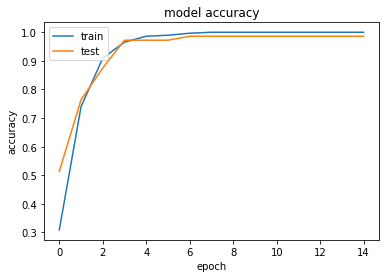

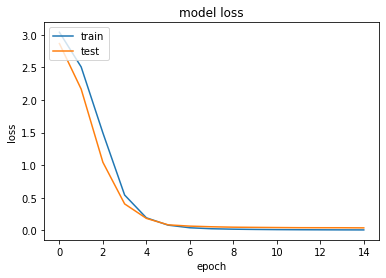

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()